In [61]:
import random
import numpy as np
import os
from os import path
import time
import copy
import torch
from torch import nn
from gan_training.utils4nb import return_data_test
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gan_training import utils
from gan_training.train import Trainer, update_average
from gan_training.logger import Logger
from gan_training.checkpoints import CheckpointIO
from gan_training.inputs import get_dataset
from gan_training.distributions import get_ydist, get_zdist
from gan_training.eval_test import DisentEvaluator, Evaluator
from gan_training.config4nb import (
    load_config, build_models, build_optimizers, build_lr_scheduler,
)


In [62]:

# Arguments

#args.config_dir='./configs'
config='cells_650.yaml'
VAEname= 'FactorVAE3'
#VAEname='BetaVAE_H'
chkptname= 'last'
config_dir='./configs'
output_dir= './outputs/'
#dvae_name= None
                   


In [63]:
#LC-136
#CellCycle-
#CPA-176-
#EMT-164-
#LiveCell -157


config_path = os.path.join(config_dir, config)
config = load_config(config_path)

nf=-1 #Base number of filters


bs=1 #'Batch size'
reg_param=-1 #'R1 regularization parameter'
w_info =-1#'weighting constant on ID Loss')
mi=max_iter=-1 #'Max training iteration')
num_workers=0 #'dataloader num_workers'
#batch_size=32 # help='batch size'

image_size= 256         #  Image size
dset_dir='./ProcessedData/'
datatype='rgb'
nc= 3

#parser.add_argument('--img_size', default=128, type=int, help='Image synthesis size')##This is the image size for which the autoencoder is designed to


c_dim= 10 #Latent synthesis size'
z_dim=256 #type=int, help='Image synthesis size')

no_cuda=False #help='Do not use cuda')
seed=1 #type=int, help='Random Seed')
infodistil_mode=True #'Infodistill')
#args = parser.parse_args()

#dvae_name='cells_trial_factor176' 
#name='GAN_Trial176_1'
TrainDataset='CCy' # Example LC, EMT, CPA
TestDataset='EMT/'
Model_dir='./Models'
dset_dir='./ProcessedData/'
#config_path = os.path.join(config_dir, config)
is_cuda = (torch.cuda.is_available() and not no_cuda)


In [64]:
VAE_chkptname='last'
GAN_chkptname='model.pt'
data_dir=os.path.join(dset_dir,TestDataset)
#out_dir = os.path.join(output_dir, name)
fvae_ckpt_path = os.path.join(Model_dir, TrainDataset, 'VAE','chkpts',VAE_chkptname)
gan_ckpt_path = os.path.join(Model_dir, TrainDataset, 'GAN','chkpts')
     


In [65]:

# Logger
checkpoint_io = CheckpointIO(
    checkpoint_dir=gan_ckpt_path
)

device = torch.device("cuda:0" if is_cuda else "cpu")

train_dataset = get_dataset(
    name='image',
    data_dir=data_dir,
    size=image_size,
)
train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=bs,
        num_workers=3,
        shuffle=True, pin_memory=True, sampler=None, drop_last=True
)



In [66]:
device = torch.device("cuda:0" if is_cuda else "cpu")
device

device(type='cuda', index=0)

In [67]:


#Create models
fvae, generator, discriminator = build_models(image_size, c_dim, nc, z_dim)
data_loader = return_data_test(TestDataset, datatype, dset_dir, bs, image_size)



In [68]:
selectVAE='fvae'

if selectVAE=='dvae':
    dvae_ckpt_path =  os.path.join()

    dvae_ckpt = torch.load(dvae_ckpt_path)
    #for key in list(dvae_ckpt_path.keys()):
    #    dvae_ckpt_path[key.replace('decoder.', 'module.decoder.'). replace('encoder.', 'module.encoder.')] = dvae_ckpt_path.pop(key)

    dvae.load_state_dict(dvae_ckpt_path)
else:

    #fvae_ckpt_path = os.path.join(output_dir, dvae_name,'chkpts', chkptname)

    fvae_ckpt = torch.load(fvae_ckpt_path)

    for key in list(fvae_ckpt['model_states']['VAE'].keys()):
        fvae_ckpt['model_states']['VAE'][key.replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.')] = fvae_ckpt['model_states']['VAE'].pop(key)


    fvae.load_state_dict(fvae_ckpt['model_states']['VAE'])

    dvae=fvae


In [69]:
# Put models on gpu if needed
dvae = dvae.to(device)
generator = generator.to(device)
discriminator = discriminator.to(device)

#g_optimizer, d_optimizer = build_optimizers(
#    generator, discriminator, dvae, config
#)

# Use multiple GPUs if possible
dvae = nn.DataParallel(dvae)
generator = nn.DataParallel(generator)
discriminator = nn.DataParallel(discriminator)

In [70]:

# Register modules to checkpoint
checkpoint_io.register_modules(
    generator=generator,
    discriminator=discriminator,

)

# Logger
logger = Logger(
    log_dir=path.join(output_dir, 'logs'),
    img_dir=path.join(output_dir, 'imgs'),
    #monitoring=config['training']['monitoring'],
    #monitoring_dir=path.join(out_dir, 'monitoring')
)


# Distributions
cdist = get_zdist('gauss',c_dim, device=device)
zdist = get_zdist('gauss', z_dim,
                  device=device)

 
# Save for tests
ntest = bs
#x_real, ytest = utils.get_nsamples(train_loader, ntest)
ztest = zdist.sample((ntest,))
ctest = cdist.sample((ntest,))
ztest_ = torch.cat([ztest, ctest], 1)

In [71]:



generator_test = generator

# Evaluator
dis_evaluator = DisentEvaluator(generator=generator_test, zdist=zdist, cdist=cdist,
                                batch_size=bs, device=device, dvae=dvae)
#data_loader = return_data_test()

# Train
tstart = t0 = time.time()
it = epoch_idx = -1

In [72]:
# Load checkpoint if existant
it = checkpoint_io.load('model.pt')
#if it != -1:
#   logger.load_stats('stats.p')
# Training loop


=> Loading checkpoint...


In [73]:
epoch_idx=0
mu_real_Dump=[]
mu_gen_Dump=[]
mu_real_All=[]
mu_gen_All=[]
label1=[]
label2=[]
label3=[]
travN_MainDir='./outputs/TraversalLoop/'
#travN_MainDir= 'Z:/COVID-FTP/Rashmi/IDGAN/outputs/'
Traversal_Save=True # Set flag to True if you wish to save traversal images to generate interpretation heatmap else set to False 



In [74]:


mu_real_All=[]
mu_gen_All=[]
label1=[]
label2=[]
#travN_MainDir='./TraversalImages/'

for x_true, path, label in data_loader:
    epoch_idx += 1

    #for x_real, _ in train_loader:
    
    x_true=x_true.to(device)

    mu_real, logvar, c_real = fvae(x_true, encode_only=True)
    
    recon_img=dis_evaluator.predict_image(c_real)
    recon_img=torch.stack(recon_img)
    #mu_gen, logvar_gen, c_gen=fvae(recon_img, encode_only=True)
    
    mu_real_All.append(mu_real.detach().cpu())
    #mu_gen_All.append(mu_gen.detach().cpu())
    
    
    mu, c_lat=dis_evaluator.predict_latent(x_true)
    if Traversal_Save:
        if epoch_idx < 50:
            
            travN =  epoch_idx
            travN_dir = os.path.join(travN_MainDir, str(travN))
            #print('checkpoint_dir',checkpoint_dir)
            # Create missing directories
            #if not os.path.exists(travN_dir):
            #    os.makedirs(travN_dir)
                
            c_lat_sample=c_lat
            z_sample=ztest[0]
            #c_lat_sample=c_lat_sample.unsqueeze(0)
            z_sample=z_sample.unsqueeze(0)
            travN
            ncol=dis_evaluator.traverse_c1z1(travN, z_sample, c_lat_sample, save='True', save_type='idgan', TravImRet='True', cmap='viridis')
            print('Saving Traversal Images')

## Sorting the feature tables according to order generated in the ImageGenerator 
    label1.append(label)
    label2.append(path)

label1=np.hstack(label1)
label2=np.hstack(label2)

Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal Images
Saving Traversal

In [75]:

label1=np.hstack(label1)
label2=np.hstack(label2)
#label3=np.hstack(label3)

mu_real_All=np.vstack(mu_real_All)
LatentZ=pd.DataFrame(mu_real_All)

#Save Predicted Latent Features
#LatentZ.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Latent_EMT_Lineage2.csv')
#LabelAll=pd.DataFrame(label1)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_lineage2.csv')
#LabelAll=pd.DataFrame(label2)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineage_Cond2.csv')
#LabelAll=pd.DataFrame(label3)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineages_Paths2.csv')'''



In [58]:
embedding=dis_evaluator.reduce_latent2d(dis_evaluator.normalize_matrix(mu_real_All), dim_red='umap')


In [59]:
sns.set(font_scale = 5)
#data_real=np.hstack((embedding, labelAll[:]))
df1 = pd.DataFrame(embedding, columns=['X','Y'])
df2 = pd.DataFrame(label1, columns=['ClassLabels1'])
df3 = pd.DataFrame(label2, columns=['ClassLabels2'])
df_F=pd.concat([df1, df2, df3],axis=1)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "C:\Users\Rashmi\Anaconda\envs\torch-gpu\lib\site-packages\IPython\core\interactiveshell.py", line 3457, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Kevin Tsia\AppData\Local\Temp\ipykernel_7496\3696131405.py", line 5, in <module>
    sns.scatterplot(data=df_F, x="X", y="Y", s=50, hue="ClassLabels2", palette=('Set1'))
  File "C:\Users\Rashmi\Anaconda\envs\torch-gpu\lib\site-packages\seaborn\_decorators.py", line 46, in inner_f
    return f(**kwargs)
  File "C:\Users\Rashmi\Anaconda\envs\torch-gpu\lib\site-packages\seaborn\relational.py", line 827, in scatterplot
    p.plot(ax, kwargs)
  File "C:\Users\Rashmi\Anaconda\envs\torch-gpu\lib\site-packages\seaborn\relational.py", line 670, in plot
    self.add_legend_data(ax)
  File "C:\Users\Rashmi\Anaconda\envs\torch-gpu\lib\site-packages\seaborn\relational.py", line 337, in add_legend_data
    artist = func([], [], label=label, **use_kws)
  File "C:\Users\Rashm

TypeError: object of type 'NoneType' has no len()

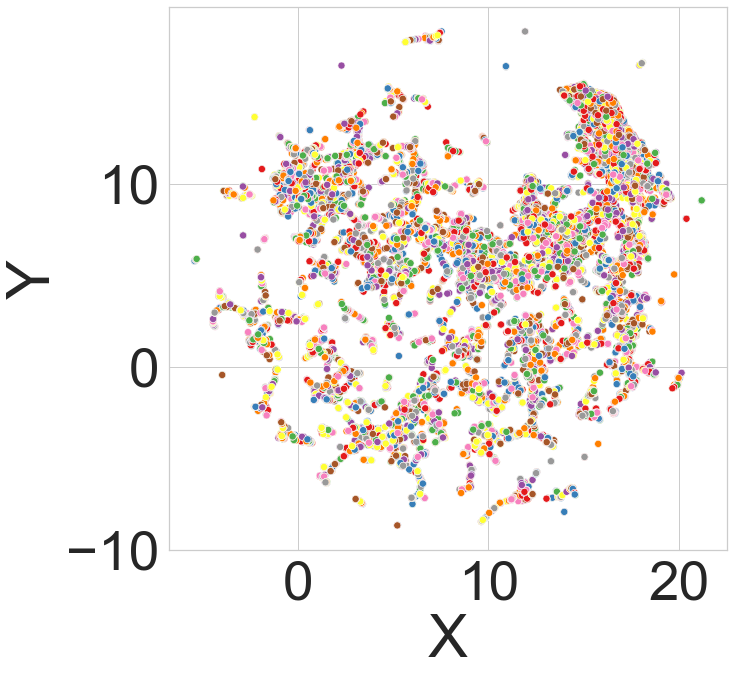

In [60]:
plt.figure(figsize=(10,10))
#plt.axis('off')
sns.set_style("whitegrid")

sns.scatterplot(data=df_F, x="X", y="Y", s=50, hue="ClassLabels2", palette=('Set1'))
plt.legend(markerscale=3, fontsize=30)

In [ ]:
mu_real_All.shape

In [ ]:

sns.set(font_scale=5)

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import pandas as pd
plt.grid(None)
#plt.axis('off')


# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(mu_real_All, label2, test_size=0.2, random_state=1)
clf = DecisionTreeClassifier(criterion='gini', max_depth=7)
clf.fit(X_train, y_train)  # celltype
pd.Series(clf.feature_importances_, index=LatentZ.columns).plot.bar(color='steelblue', figsize=(12, 6))
plt.show()
y_pred = clf.predict(X_test)


print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix,plot_confusion_matrix
plt.figure(figsize=(5,5))
ax = plt.subplot()

sns.set(font_scale=1.0) # Adjust to fit
y_pred= clf.predict(X_test)

cm=confusion_matrix(y_test, y_pred)

df=pd.DataFrame(cm)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cmn, annot=True, fmt='.2f', ax=ax, cmap="Reds");  # annot=True to annotate cells

#plt.axis('off')

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('Observed labels');
ax.set_title('Confusion Matrix');
#ax.xaxis.set_ticklabels(label1);
#ax.yaxis.set_ticklabels(label1);


plt.show()